# Learning-rate comparison with crop augmentation

Upload `hyperparameter_review.py` into the runtime's `roof_utils/` folder (or `/content`, where setup can place it). Restart the kernel and run the setup cells in order. Preserve the current utility versions; do not edit them while a training experiment is running. The project/data paths come from `.env`. No Drive mount is required.

The selected crop-enabled recipe is the reference. Threshold tuning and these comparisons are development analyses, not an independent final-test evaluation. Existing model checkpoints and original metrics are preserved.

We vary one factor: multiply both fine-tuning learning rates by three, preserving their ratio. The decoder warm-up learning rate stays at 1e-3. Crop probability, crop size, seed, folds, threshold, batch size, maximum epochs, and stopping rules match. We are not running an additional seed or a large search.

For a clean matched comparison this notebook trains two new five-fold runs with the currently uploaded code. Your old results remain available, but are not silently reused across code/configuration changes. This costs ten fold fits; each may stop early. Runs resume when settings/code remain unchanged.

In [1]:
# Run this before importing project modules. Preserve Colab's working CUDA stack.
import sys, subprocess, importlib.util
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy>=1.24,<3', 'Pillow>=10,<13', 'matplotlib>=3.8,<4'])
if any(importlib.util.find_spec(name) is None for name in ('torch', 'torchvision')):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torch==2.8.0', 'torchvision==0.23.0'])
# If pip requests a kernel restart, restart and rerun from here.


In [2]:
from pathlib import Path
import os
import sys
import importlib
import shutil

# Set this only if automatic discovery finds no project or multiple projects.
PROJECT_ROOT_OVERRIDE = os.environ.get('DIDA_PROJECT_ROOT', '')
if PROJECT_ROOT_OVERRIDE:
    candidates = [Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()]
else:
    candidates = [Path.cwd(), *Path.cwd().parents]
    if Path('/content').is_dir():
        candidates += [p.parent for p in Path('/content').rglob('pyproject.toml')]
roots = sorted({p.resolve() for p in candidates
                if (p / 'pyproject.toml').is_file() and (p / 'roof_utils').is_dir()})
if len(roots) != 1:
    raise RuntimeError(
        f'Found project roots: {roots}. Set PROJECT_ROOT_OVERRIDE to the runtime '
        'project directory. If none exist, upload the project/data to this Colab server.')
PROJECT_ROOT = roots[0]

# A file uploaded separately through VS Code may land at /content instead.
module_file = PROJECT_ROOT / 'roof_utils' / 'hyperparameter_review.py'
uploaded = Path('/content/hyperparameter_review.py')
if not module_file.is_file() and uploaded.is_file():
    if 'def threshold_sweep(' not in uploaded.read_text():
        raise ValueError('Uploaded hyperparameter_review.py does not contain the expected utility.')
    shutil.copy2(uploaded, module_file)
if not module_file.is_file():
    raise FileNotFoundError(f'Upload hyperparameter_review.py to {module_file}')

sys.path.insert(0, str(PROJECT_ROOT))
importlib.invalidate_caches()
import roof_utils
if Path(roof_utils.__file__).resolve().parent != PROJECT_ROOT / 'roof_utils':
    raise RuntimeError('A different roof_utils is cached. Restart the kernel and rerun in order.')
from roof_utils.config import load_paths

env_file = PROJECT_ROOT / '.env'
if not env_file.exists():
    env_file.write_text(
        'RAW_DATA_DIR=data\nPREPARED_DATA_DIR=data_preparation_outputs\n'
        'MODELS_DIR=models\nREPORTS_DIR=reports\n')
paths = load_paths(PROJECT_ROOT)
for directory in (paths.raw_data_dir, paths.prepared_data_dir):
    if not directory.is_dir():
        raise FileNotFoundError(f'{directory} is unavailable. Check runtime paths in {env_file}.')
print('Project:', PROJECT_ROOT)
print('Models:', paths.models_dir)
print('Reports:', paths.reports_dir)


Project: /content
Models: /content/models
Reports: /content/reports


In [3]:
from roof_utils.hyperparameter_review import (
    threshold_sweep, plot_threshold_sweep, learning_rate_configs,
    compare_learning_rates, plot_learning_rate_comparison,
)
from roof_utils.cross_validation import CVConfig, run_cross_validation, plot_history, show_predictions
print('Reports directory:', paths.reports_dir)


Reports directory: /content/reports


In [4]:
import torch
assert torch.cuda.is_available(), 'Select the Colab GPU kernel before training.'
print('GPU:', torch.cuda.get_device_name(0))
REFERENCE_RUN = 'crop_lr_reference_500'
CANDIDATE_RUN = 'crop_lr_3x_500'
REFERENCE_CONFIG, CANDIDATE_CONFIG = learning_rate_configs(CVConfig(
    crop_probability=0.3,
    threshold=0.45,
    monitor='val_loss',
    min_epochs=30,
    patience=20,
    max_epochs=500,
    encoder_lr=1e-5,
    decoder_lr=1e-4,
))
FOLDS = [0, 1, 2, 3, 4]
print('Reference:', REFERENCE_CONFIG)
print('Candidate:', CANDIDATE_CONFIG)


GPU: Tesla T4
Reference: CVConfig(seed=42, max_epochs=500, warmup_epochs=5, patience=20, monitor='val_loss', min_epochs=30, threshold=0.45, batch_size=4, crop_probability=0.3, encoder_lr=1e-05, warmup_decoder_lr=0.001, decoder_lr=0.0001, weight_decay=0.0001)
Candidate: CVConfig(seed=42, max_epochs=500, warmup_epochs=5, patience=20, monitor='val_loss', min_epochs=30, threshold=0.45, batch_size=4, crop_probability=0.3, encoder_lr=3.0000000000000004e-05, warmup_decoder_lr=0.001, decoder_lr=0.00030000000000000003, weight_decay=0.0001)


## Run the reference recipe

In [5]:
reference_summary = run_cross_validation(paths, REFERENCE_RUN, REFERENCE_CONFIG, folds=FOLDS, device="cuda")

fold 0 | epoch   1 | val loss 0.6212 | val IoU 0.3198 | roof 16.18% | best val_loss 0.6212 (epoch 1)
fold 0 | epoch   2 | val loss 0.5698 | val IoU 0.4112 | roof 17.10% | best val_loss 0.5698 (epoch 2)
fold 0 | epoch   3 | val loss 0.5475 | val IoU 0.4101 | roof 22.75% | best val_loss 0.5475 (epoch 3)
fold 0 | epoch   4 | val loss 0.5068 | val IoU 0.4905 | roof 19.35% | best val_loss 0.5068 (epoch 4)
fold 0 | epoch   5 | val loss 0.5034 | val IoU 0.4787 | roof 22.41% | best val_loss 0.5034 (epoch 5)
fold 0 | epoch   6 | val loss 0.4991 | val IoU 0.4936 | roof 21.52% | best val_loss 0.4991 (epoch 6)
fold 0 | epoch   7 | val loss 0.4957 | val IoU 0.5053 | roof 20.43% | best val_loss 0.4957 (epoch 7)
fold 0 | epoch   8 | val loss 0.4941 | val IoU 0.5101 | roof 19.87% | best val_loss 0.4941 (epoch 8)
fold 0 | epoch   9 | val loss 0.4923 | val IoU 0.5165 | roof 19.92% | best val_loss 0.4923 (epoch 9)
fold 0 | epoch  10 | val loss 0.4896 | val IoU 0.5247 | roof 19.90% | best val_loss 0.4896 

## Run the higher learning-rate recipe

In [6]:
candidate_summary = run_cross_validation(paths, CANDIDATE_RUN, CANDIDATE_CONFIG, folds=FOLDS, device="cuda")

fold 0 | epoch   1 | val loss 0.6209 | val IoU 0.3209 | roof 16.50% | best val_loss 0.6209 (epoch 1)
fold 0 | epoch   2 | val loss 0.5702 | val IoU 0.4055 | roof 17.78% | best val_loss 0.5702 (epoch 2)
fold 0 | epoch   3 | val loss 0.5441 | val IoU 0.4210 | roof 22.20% | best val_loss 0.5441 (epoch 3)
fold 0 | epoch   4 | val loss 0.5079 | val IoU 0.4814 | roof 20.07% | best val_loss 0.5079 (epoch 4)
fold 0 | epoch   5 | val loss 0.5180 | val IoU 0.4432 | roof 22.37% | best val_loss 0.5079 (epoch 4)
fold 0 | epoch   6 | val loss 0.5014 | val IoU 0.4866 | roof 19.71% | best val_loss 0.5014 (epoch 6)
fold 0 | epoch   7 | val loss 0.4834 | val IoU 0.5431 | roof 19.19% | best val_loss 0.4834 (epoch 7)
fold 0 | epoch   8 | val loss 0.4756 | val IoU 0.5473 | roof 21.10% | best val_loss 0.4756 (epoch 8)
fold 0 | epoch   9 | val loss 0.4691 | val IoU 0.5616 | roof 20.81% | best val_loss 0.4691 (epoch 9)
fold 0 | epoch  10 | val loss 0.4604 | val IoU 0.5896 | roof 19.47% | best val_loss 0.4604 

## Compare both at the fixed threshold 0.45

Requires all five folds and matching metadata except encoder/decoder fine-tuning learning rates. If either run reports changed configuration/code/software, choose new names for the matched pair rather than deleting its experiment metadata.

Fold  Reference IoU  Candidate IoU  Change
   0  0.8275         0.8424         +0.0149
   1  0.7300         0.7505         +0.0204
   2  0.7898         0.8078         +0.0181
   3  0.7043         0.7728         +0.0685
   4  0.7960         0.8250         +0.0290
All-image means: {'reference_iou': 0.7671052675335382, 'candidate_iou': 0.7979114058405999, 'delta_iou': 0.03080613830706168}
Images improved: 19 / 24


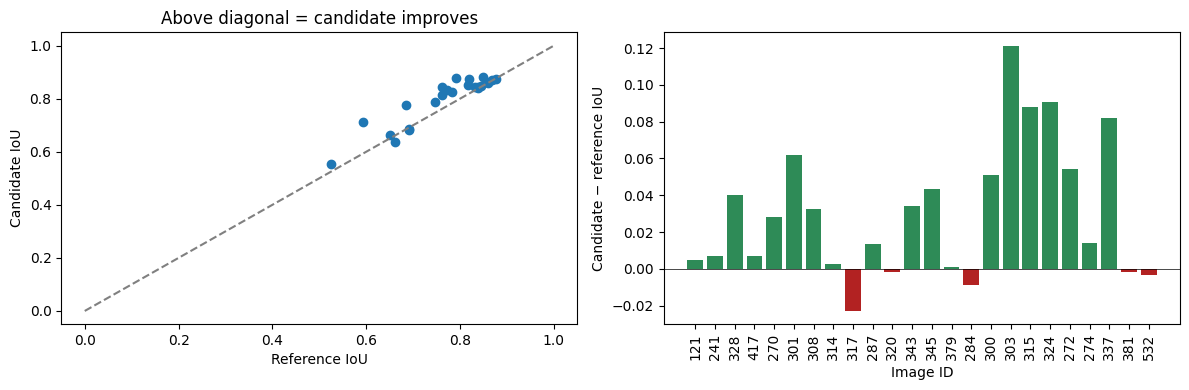

In [7]:
comparison = compare_learning_rates(paths, REFERENCE_RUN, CANDIDATE_RUN, threshold=0.45)
plot_learning_rate_comparison(comparison)


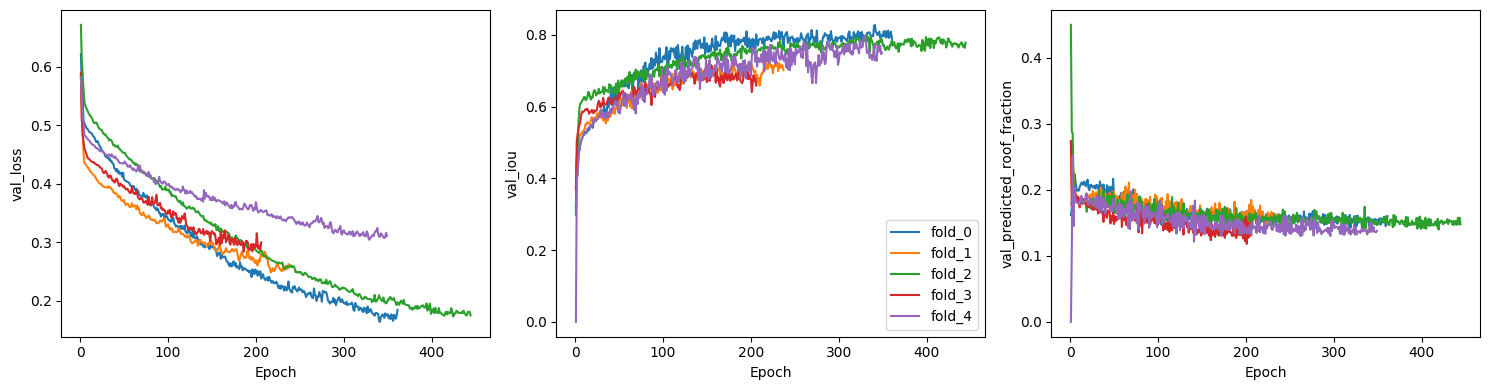

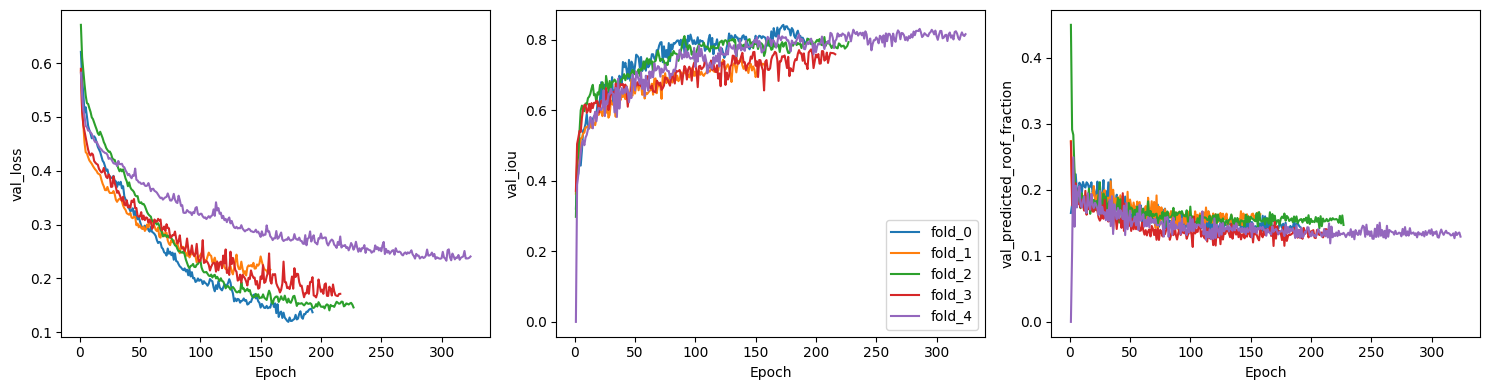

In [8]:
plot_history(paths, REFERENCE_RUN)
plot_history(paths, CANDIDATE_RUN)


In [9]:
import json
from pathlib import Path
import numpy as np

REFERENCE_RUN = "crop_lr_reference_500"
CANDIDATE_RUN = "crop_lr_3x_500"


def load_fold_result(run_name, fold):
    file = paths.reports_dir / run_name / f"fold_{fold}" / "result.json"
    result = json.loads(file.read_text())

    if result.get("monitor") != "val_loss":
        raise ValueError(f"{run_name}, fold {fold}: not selected by val_loss")

    if "selected_val_loss" not in result:
        raise KeyError(f"{file}: missing selected_val_loss")

    return result


rows = []

print("Fold  Reference loss  Candidate loss  Change     Best epochs (ref/cand)")

for fold in range(5):
    reference = load_fold_result(REFERENCE_RUN, fold)
    candidate = load_fold_result(CANDIDATE_RUN, fold)

    ref_loss = reference["selected_val_loss"]
    cand_loss = candidate["selected_val_loss"]
    delta = cand_loss - ref_loss

    rows.append({
        "fold": fold,
        "reference_loss": ref_loss,
        "candidate_loss": cand_loss,
        "delta_loss": delta,
    })

    print(
        f"{fold:4d}  {ref_loss:.4f}          {cand_loss:.4f}          "
        f"{delta:+.4f}     "
        f"{reference['best_epoch']}/{candidate['best_epoch']}"
    )

ref_mean = np.mean([r["reference_loss"] for r in rows])
cand_mean = np.mean([r["candidate_loss"] for r in rows])

print(f"\nMean across folds: reference={ref_mean:.4f}, candidate={cand_mean:.4f}")
print(f"Mean change: {cand_mean - ref_mean:+.4f}")
print(
    "Folds with lower candidate loss:",
    sum(r["delta_loss"] < 0 for r in rows),
    "/ 5",
)

Fold  Reference loss  Candidate loss  Change     Best epochs (ref/cand)
   0  0.1639          0.1192          -0.0447     341/173
   1  0.2482          0.2053          -0.0428     217/138
   2  0.1736          0.1405          -0.0331     424/207
   3  0.2838          0.1646          -0.1192     186/196
   4  0.3042          0.2329          -0.0713     329/304

Mean across folds: reference=0.2347, candidate=0.1725
Mean change: -0.0622
Folds with lower candidate loss: 5 / 5


## Decide whether the higher rates help

Compare the mean change, changes across folds and individual images, and the number of epochs used. Inspect masks for the largest gains and declines before adopting a change. A small gain on one seed is uncertain; these paired images are not independent experimental repetitions.

Preserve the current final model. Only refit another final model if the learning-rate experiment gives a useful improvement. If both rates are raised, this experiment cannot tell which individual rate caused the effect.

Reports are written under the candidate run's `hyperparameter_review/lr_comparison_t0.45/`. Keep/download both run reports and checkpoints before a temporary runtime disappears.